# Car Price Prediction with Machine Learning

In [39]:
import pandas as pd

df = pd.read_csv("/content/car data.csv")

In [40]:
print(df.head())
print(df.shape)
print(df.info())
print("Duplicate Rows", df.duplicated())


  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present

In [41]:
cat_col = [col for col in df.columns if df[col].dtype == "object"]
num_col = [col for col in df.columns if df[col].dtype != "object"]
print("Categorical Columns: ", cat_col)
print("Numerical Columns: ", num_col)

# 2. Filter out IDs, codes, or binary/boolean choices (columns with very few unique values)
best_numerical_cols = [col for col in num_col if df[col].nunique() > 10]

print("Best columns to plot:", best_numerical_cols)

Categorical Columns:  ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']
Numerical Columns:  ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']
Best columns to plot: ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms']


In [42]:
print("Number of unique values", df[cat_col].nunique())
print("Missing Values Percentage: ", round((df.isnull().sum()/df.shape[0]*100)))


Number of unique values Car_Name        98
Fuel_Type        3
Selling_type     2
Transmission     2
dtype: int64
Missing Values Percentage:  Car_Name         0.0
Year             0.0
Selling_Price    0.0
Present_Price    0.0
Driven_kms       0.0
Fuel_Type        0.0
Selling_type     0.0
Transmission     0.0
Owner            0.0
dtype: float64


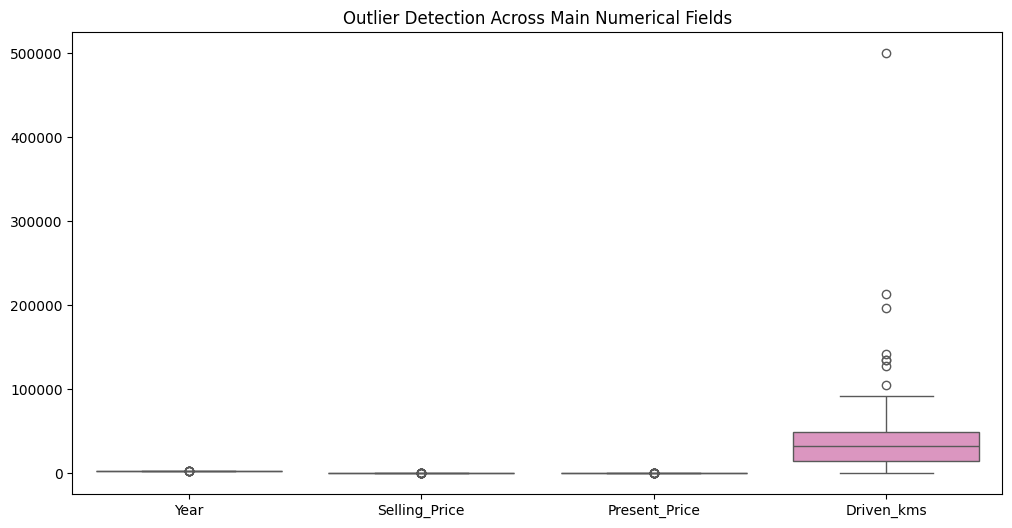

In [43]:
# Detecting Outliers with BOX PLOT
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[best_numerical_cols], orient="v", palette="Set2")
plt.title("Outlier Detection Across Main Numerical Fields")
plt.show()

Remaining columns in df2:
 ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Owner            0
dtype: int64


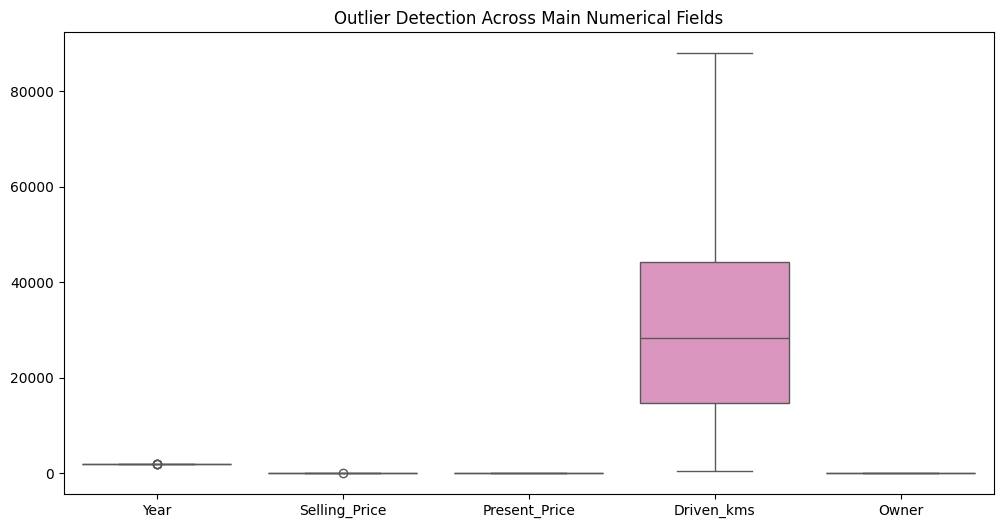

In [44]:
# Copy the original dataframe to keep it safe
df2 = df.copy()

# Ensure num_col is treated as a list, even if it's just one column
columns_to_filter = [num_col] if isinstance(num_col, str) else num_col

# Loop through each numerical column to remove outliers sequentially
for col in columns_to_filter:
    mean = df2[col].mean()
    std = df2[col].std()

    Lower_bound = mean - (2 * std)
    Upper_bound = mean + (2 * std)

    # Create a 1-dimensional condition for this specific column
    condition = (df2[col] >= Lower_bound) & (df2[col] <= Upper_bound)

    # Filter rows safely using the 1D condition
    df2 = df2.loc[condition, :]

# Verify the final columns to prove categories are still there
print("Remaining columns in df2:\n", df2.columns.tolist())



print(df2[num_col].isnull().sum())

# Detecting Outliers with BOX PLOT
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df2[columns_to_filter], orient="v", palette="Set2")
plt.title("Outlier Detection Across Main Numerical Fields")
plt.show()



In [45]:
# 1. Feature engineering
df['Car_Age'] = 2026 - df['Year']

# 2. Drop columns we don't want as features
df_features = df.drop(columns=['Year', 'Car_Name'])

# 3. One-hot encode nominal categorical columns
df_encoded = pd.get_dummies(
    df_features,
    columns=['Fuel_Type', 'Selling_type', 'Transmission'],
    drop_first=True
)

# 4. Define X (Features) and y (Target)
X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']


In [46]:
# Train-Test Split & Feature Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling (Fit ONLY on Train, Transform BOTH Train and Test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Ridge Regression (Handles Multicollinearity between features like horsepower and engine size)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# 3. Random Forest (Non-Linear baseline)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Tree models don't require feature scaling

RandomForestRegressor(random_state=42)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Define the evaluation function properly
def evaluate_model(name, model, X_test_data, y_true):
    # Predict in original price scale
    preds = model.predict(X_test_data)

    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    print(f"--- {name} Performance ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}\n")


# 2. Call the function sequentially for each model
evaluate_model("Linear Regression", lr_model, X_test_scaled, y_test)

evaluate_model("Random Forest", rf_model, X_test, y_test)


--- Linear Regression Performance ---
MAE: 1.2164
RMSE: 1.8658
R² Score: 0.8489

--- Random Forest Performance ---
MAE: 0.6369
RMSE: 0.9664
R² Score: 0.9595



In [49]:
# Checking actual vs predicted prices
rf_predictions = rf_model.predict(X_test)

import pandas as pd

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': rf_predictions
})

comparison.head(10)

comparison['Error'] = (
    comparison['Actual Price'] - comparison['Predicted Price']
)

comparison['Absolute Error'] = comparison['Error'].abs()

comparison.head(10)



,Actual Price,Predicted Price,Error,Absolute Error
0,0.35,0.4438,-0.0938,0.0938
1,10.11,10.9098,-0.7998,0.7998
2,4.95,4.9315,0.0185,0.0185
3,0.15,0.2159,-0.0659,0.0659
4,6.95,7.7988,-0.8488,0.8488
5,7.45,6.2535,1.1965,1.1965
6,1.10,1.1065,-0.0065,0.0065
7,0.50,0.5876,-0.0876,0.0876
8,0.45,0.4690,-0.0190,0.0190
9,6.00,6.8960,-0.8960,0.8960
